<a href="https://colab.research.google.com/github/rdityaza/AI-For-Business/blob/main/Praktikum2_18223050_18223086.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Prediksi Kebangkrutan Perusahaan
**Praktikum 2 — Kelompok 8**
M Ikhbar A | 18223050
Raditya Zaki Athaya | 18223086
---
##  Deskripsi Proyek
Notebook ini membangun model klasifikasi untuk memprediksi apakah suatu perusahaan akan **bangkrut (B)** atau **tidak bangkrut (NB)** berdasarkan 6 faktor risiko kategorik.

### Fitur yang Digunakan
| Fitur | Deskripsi | Nilai |
|---|---|---|
| Industrial Risk | Risiko dari sektor industri | N / A / P |
| Management Risk | Risiko dari manajemen perusahaan | N / A / P |
| Financial Flexibility | Fleksibilitas keuangan perusahaan | N / A / P |
| Credibility | Kredibilitas perusahaan | N / A / P |
| Competitiveness | Daya saing perusahaan | N / A / P |
| Operating Risk | Risiko operasional | N / A / P |

> **Keterangan nilai:** `N` = Negatif, `A` = Average, `P` = Positif

### Target
- `B` → Bankrupt (Bangkrut)
- `NB` → Non-Bankrupt (Tidak Bangkrut)

---
## 1. Setup & Import Library

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from sklearn import linear_model as lm
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as sts
import pandas as pd
import scipy as scp
import numpy as np
import sklearn.preprocessing as preproc
from sklearn.model_selection import train_test_split, StratifiedKFold  ### for train and test split package
from sklearn import metrics  ## For calculation of MSE & RMSE
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import confusion_matrix, f1_score

---
## 2. Load & Eksplorasi Data Awal

In [ ]:
train = pd.read_csv("/content/drive/MyDrive/Praktikum 2_Kelompok 8/bankruptcy_data.csv")

print(f' Dimensi Dataset: {train.shape[0]} baris × {train.shape[1]} kolom')
train.head()

 Dimensi Dataset: 250 baris × 7 kolom


,Industrial Risk,Management Risk,Financial Flexibility,Credibility,Competitiveness,Operating Risk,Class
0,P,P,A,A,A,P,NB
1,N,N,A,A,A,N,NB
2,A,A,A,A,A,A,NB
3,P,P,P,P,P,P,NB
4,N,N,P,P,P,N,NB


In [ ]:
train.shape

(250, 7)

In [ ]:
for col in train:
    print (col)
    print (train[col].unique())

Industrial Risk
['P' 'N' 'A']
Management Risk
['P' 'N' 'A']
Financial Flexibility
['A' 'P' 'N']
Credibility
['A' 'P' 'N']
Competitiveness
['A' 'P' 'N']
Operating Risk
['P' 'N' 'A']
Class
['NB' 'B']


In [ ]:
train.describe()

,Industrial Risk,Management Risk,Financial Flexibility,Credibility,Competitiveness,Operating Risk,Class
count,250,250,250,250,250,250,250
unique,3,3,3,3,3,3,2
top,N,N,N,N,N,N,NB
freq,89,119,119,94,103,114,143


In [ ]:
train.columns

Index(['Industrial Risk', 'Management Risk', 'Financial Flexibility',
       'Credibility', 'Competitiveness', 'Operating Risk', 'Class'],
      dtype='object')

---
## 3. Preprocessing Data

### 3.1 Ordinal Encoding
Karena semua fitur bersifat **ordinal kategorik** (N < A < P), kita gunakan `OrdinalEncoder` untuk mengubahnya menjadi nilai numerik:
- `N` (Negatif) → `0`
- `A` (Average) → `1`
- `P` (Positif) → `2`

Target `Class` juga diubah menjadi biner:
- `NB` (Non-Bankrupt) → `0`
- `B` (Bankrupt) → `1`

In [ ]:
feature_cols = ['Industrial Risk', 'Management Risk', 'Financial Flexibility',
                'Credibility', 'Competitiveness', 'Operating Risk']

ordinal_categories = [['N', 'A', 'P']] * len(feature_cols)
enc = OrdinalEncoder(categories=ordinal_categories)
train[feature_cols] = enc.fit_transform(train[feature_cols])

train['Class'] = (train['Class'] == 'B').astype(int)

In [ ]:
print("Data setelah Ordinal Encoding:")
print(train.head())
print(f"\nDistribusi target:\n{train['Class'].value_counts()}")

Data setelah Ordinal Encoding:
   Industrial Risk  Management Risk  Financial Flexibility  Credibility  \
0              2.0              2.0                    1.0          1.0   
1              0.0              0.0                    1.0          1.0   
2              1.0              1.0                    1.0          1.0   
3              2.0              2.0                    2.0          2.0   
4              0.0              0.0                    2.0          2.0   

   Competitiveness  Operating Risk  Class  
0              1.0             2.0      0  
1              1.0             0.0      0  
2              1.0             1.0      0  
3              2.0             2.0      0  
4              2.0             0.0      0  

Distribusi target:
Class
0    143
1    107
Name: count, dtype: int64


In [ ]:
train.isnull().any()

,0
Industrial Risk,False
Management Risk,False
Financial Flexibility,False
Credibility,False
Competitiveness,False
Operating Risk,False
Class,False


---
## 4. Exploratory Data Analysis (EDA)

Bagian ini mengeksplorasi distribusi data dan hubungan antar fitur dengan target untuk mendapatkan insight awal sebelum pemodelan.

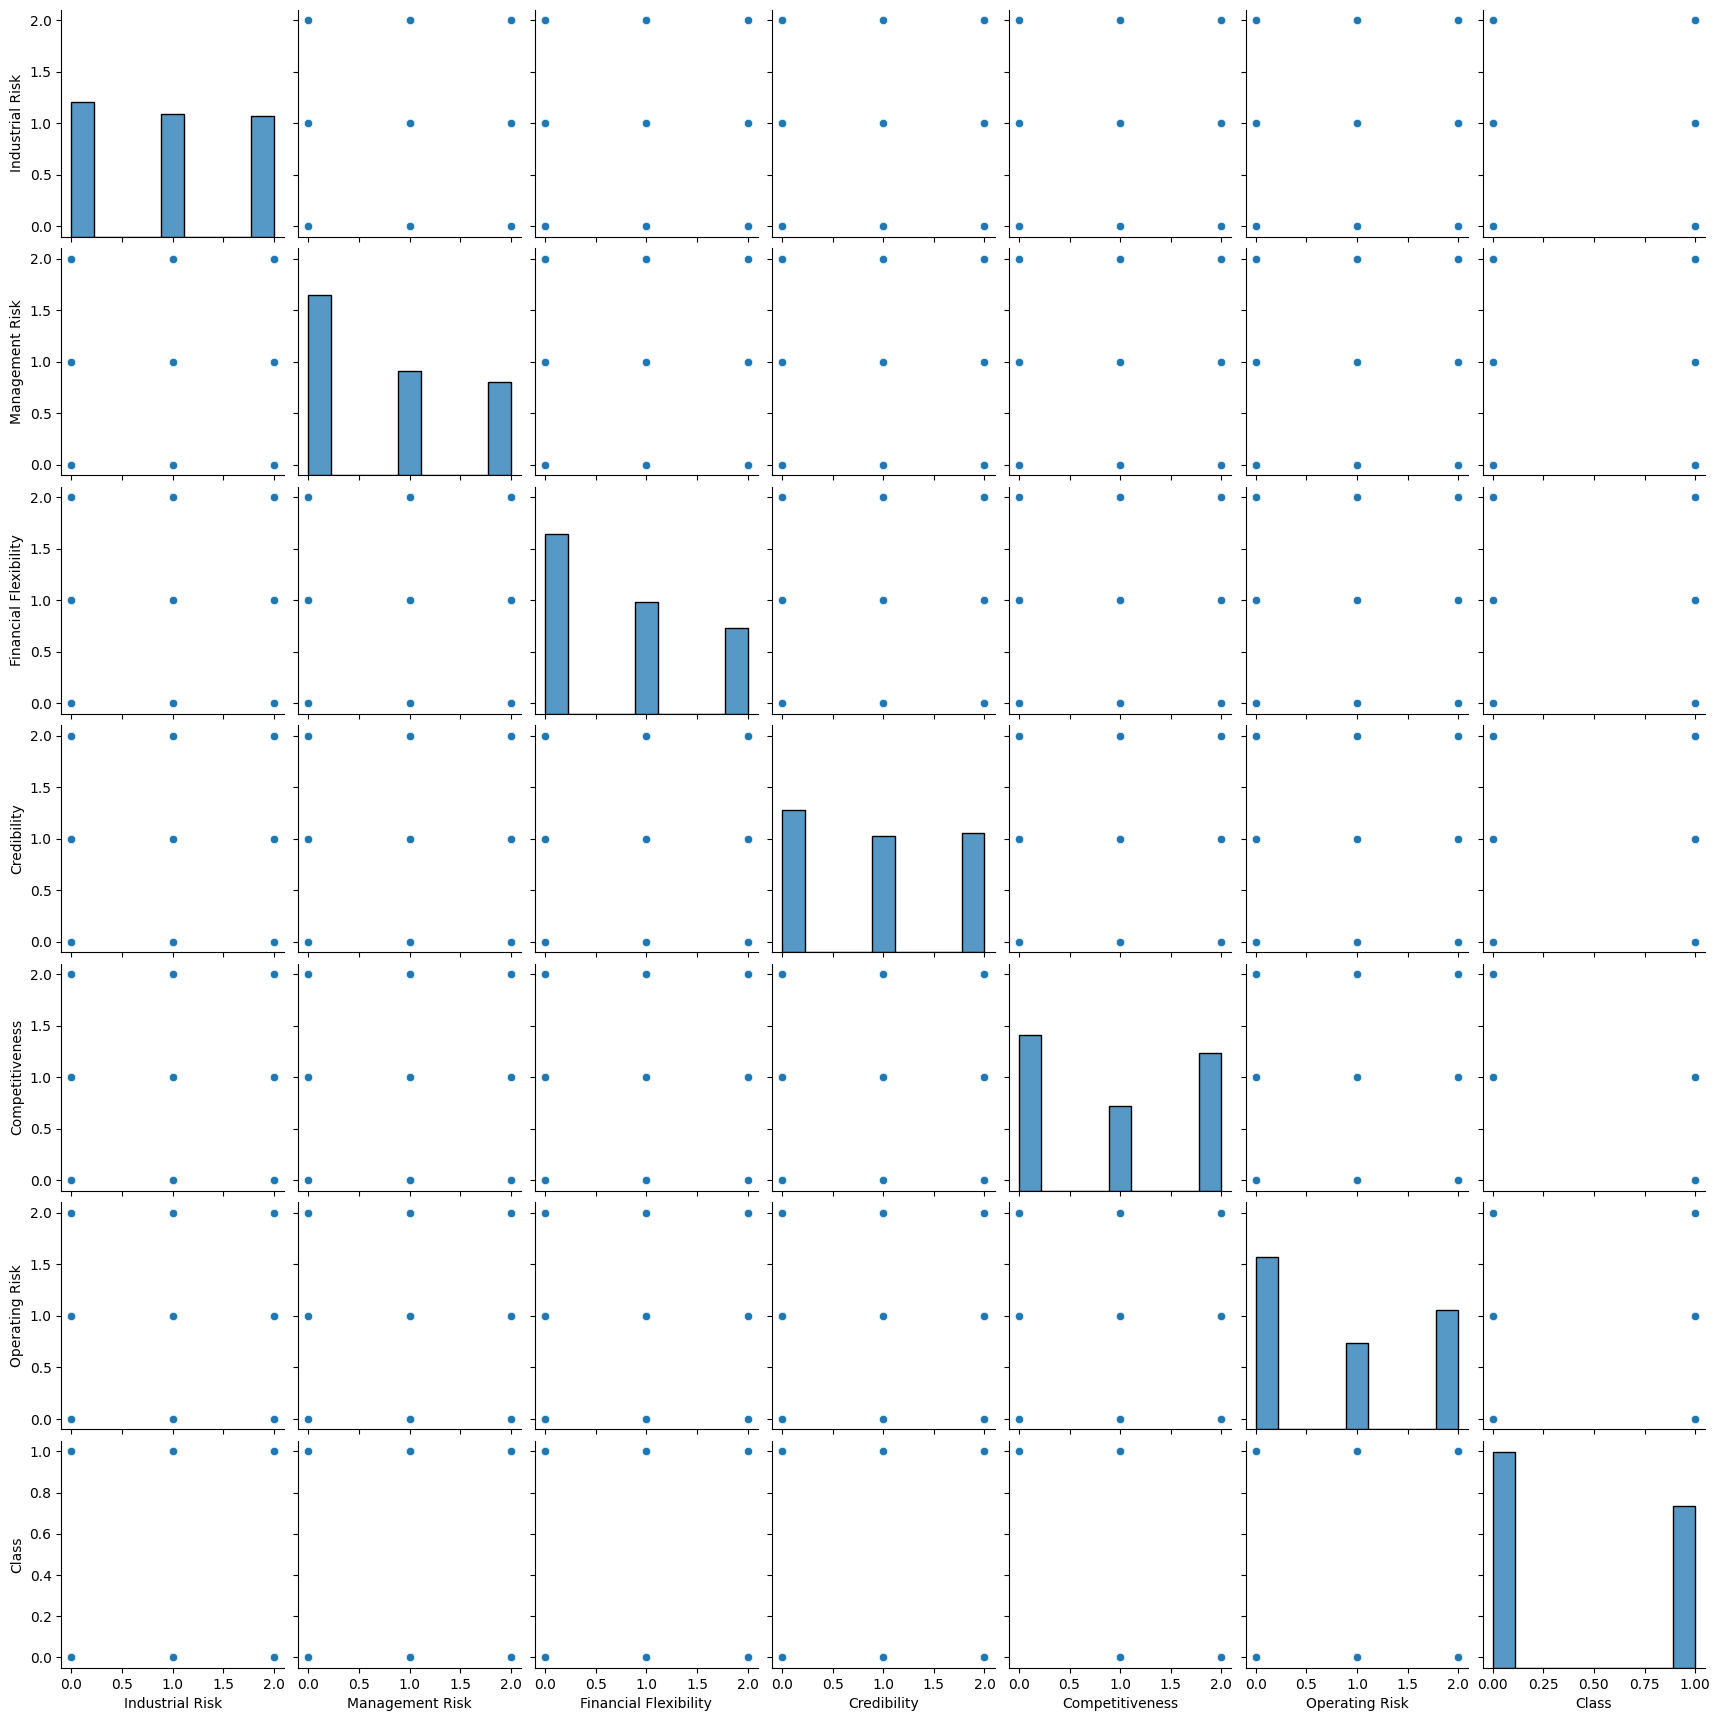

In [ ]:
sns.pairplot(train)

In [ ]:
train.corr()

,Industrial Risk,Management Risk,Financial Flexibility,Credibility,Competitiveness,Operating Risk,Class
Industrial Risk,1.000000,0.255127,0.162624,0.014438,0.257814,0.144507,-0.227823
Management Risk,0.255127,1.000000,0.254845,0.303341,0.306568,0.213874,-0.370838
Financial Flexibility,0.162624,0.254845,1.000000,0.524951,0.686612,0.116903,-0.751020
Credibility,0.014438,0.303341,0.524951,1.000000,0.675689,0.288458,-0.755909
Competitiveness,0.257814,0.306568,0.686612,0.675689,1.000000,0.211383,-0.899452
Operating Risk,0.144507,0.213874,0.116903,0.288458,0.211383,1.000000,-0.279786
Class,-0.227823,-0.370838,-0.751020,-0.755909,-0.899452,-0.279786,1.000000


### 4.2 Proporsi Kelas per Fitur
Grafik batang bertumpuk ini menunjukkan **proporsi perusahaan bangkrut vs tidak bangkrut** untuk setiap nilai (N, A, P) pada masing-masing fitur.

> **Insight yang diharapkan:** Nilai `N` (Negatif) seharusnya didominasi oleh kelas Bankrupt, sementara nilai `P` (Positif) didominasi Non-Bankrupt.

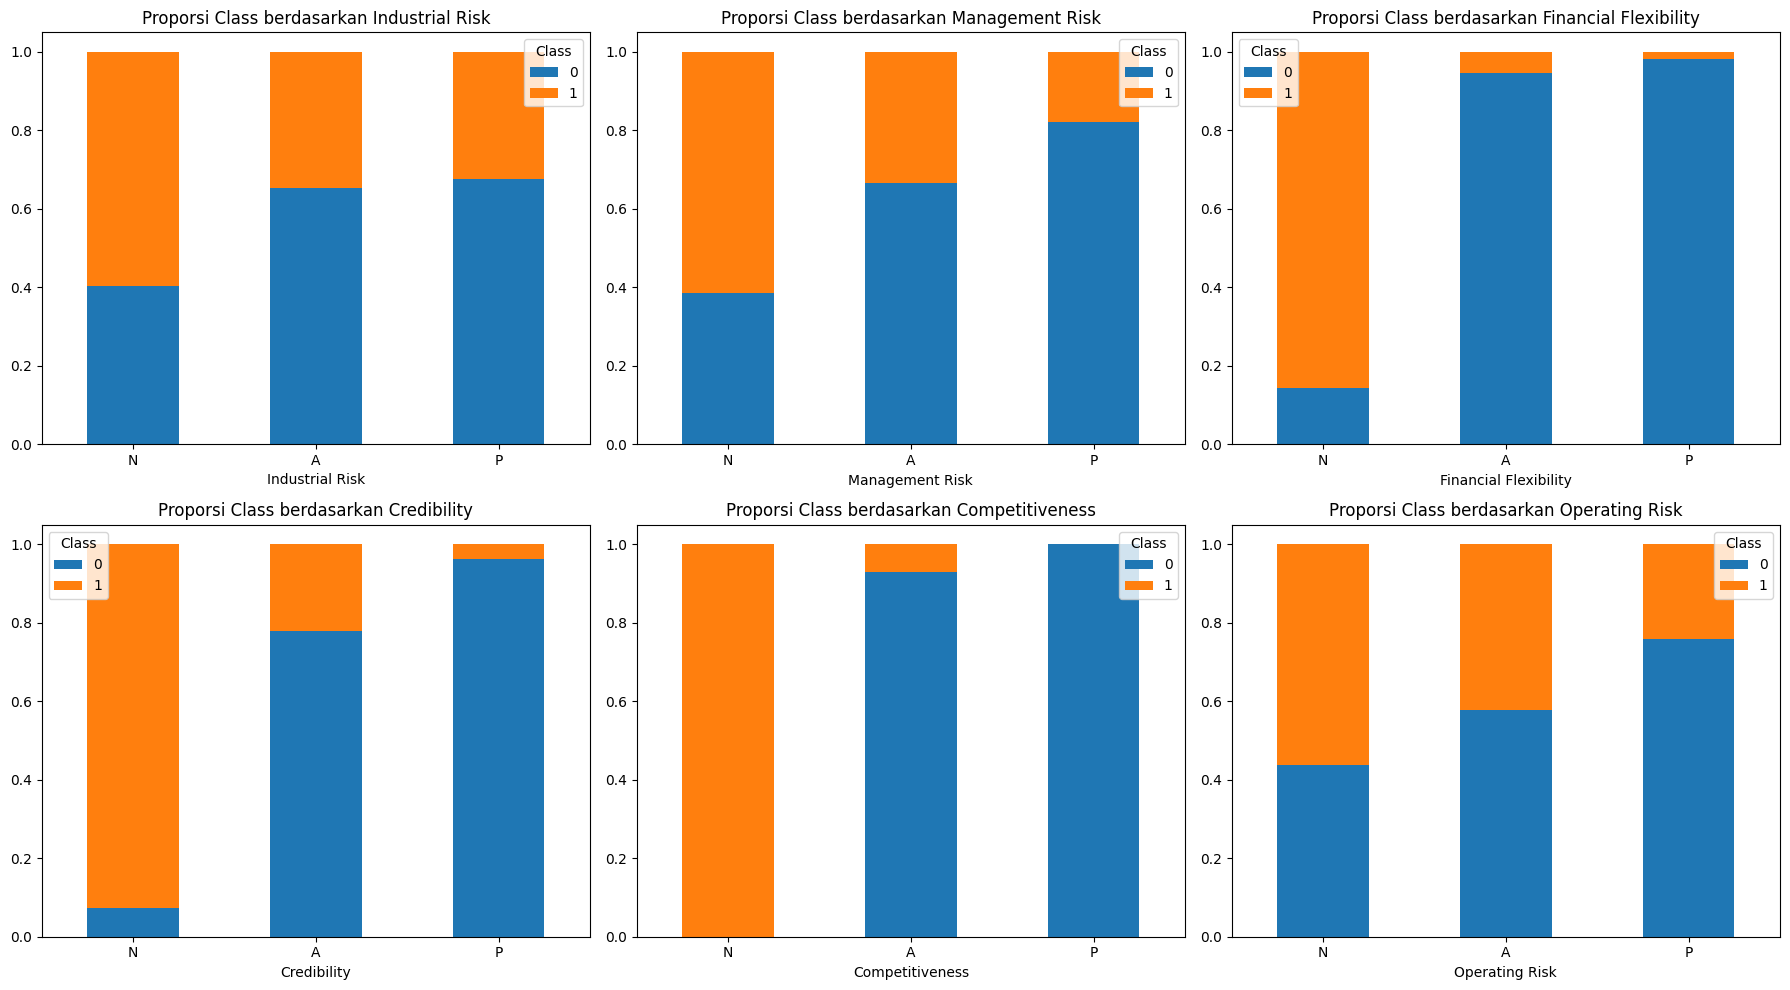

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = feature_cols
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    # Cross-tabulation antara fitur dan target
    ct = pd.crosstab(train[col], train['Class'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#1f77b4', '#ff7f0e'])
    axes[i].set_title(f'Proporsi Class berdasarkan {col}')
    axes[i].set_xticklabels(['N', 'A', 'P'], rotation=0)

plt.tight_layout()
plt.show()

### 4.3 Radar Chart — Profil Risiko Rata-rata
Radar chart ini membandingkan **rata-rata nilai setiap fitur** antara perusahaan bangkrut dan tidak bangkrut.

> **Interpretasi:** Area yang lebih luas menandakan nilai rata-rata fitur yang lebih tinggi (lebih positif). Perusahaan Non-Bankrupt seharusnya memiliki area yang lebih besar.

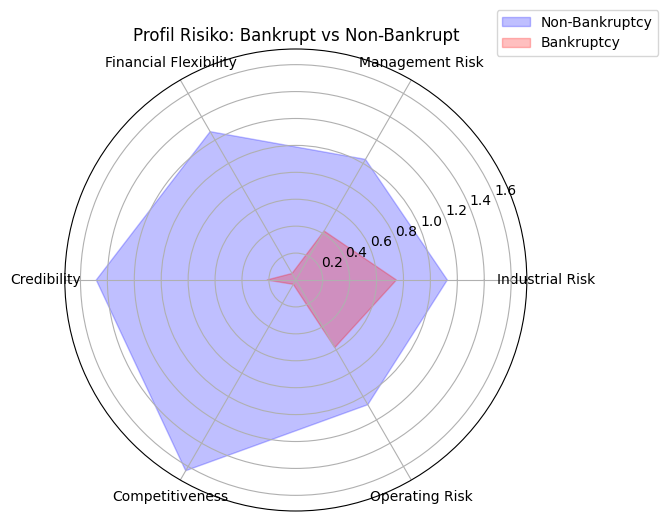

In [ ]:
# Hitung rata-rata tiap fitur untuk setiap kelas
df_radar = train.groupby('Class')[feature_cols].mean().reset_index()

# Plotting sederhana menggunakan plotly (opsional) atau matplotlib
labels=np.array(feature_cols)
stats_nb = df_radar.loc[0, feature_cols].values
stats_b = df_radar.loc[1, feature_cols].values

angles=np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
stats_nb=np.concatenate((stats_nb,[stats_nb[0]]))
stats_b=np.concatenate((stats_b,[stats_b[0]]))
angles=np.concatenate((angles,[angles[0]]))

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.fill(angles, stats_nb, color='blue', alpha=0.25, label='Non-Bankruptcy')
ax.fill(angles, stats_b, color='red', alpha=0.25, label='Bankruptcy')
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("Profil Risiko: Bankrupt vs Non-Bankrupt")
plt.show()

### 4.4 Heatmap — Probabilitas Kebangkrutan (Competitiveness vs Financial Flexibility)
Tabel silang ini menunjukkan **rata-rata proporsi kebangkrutan** pada kombinasi nilai dua fitur yang paling berkorelasi dengan target.

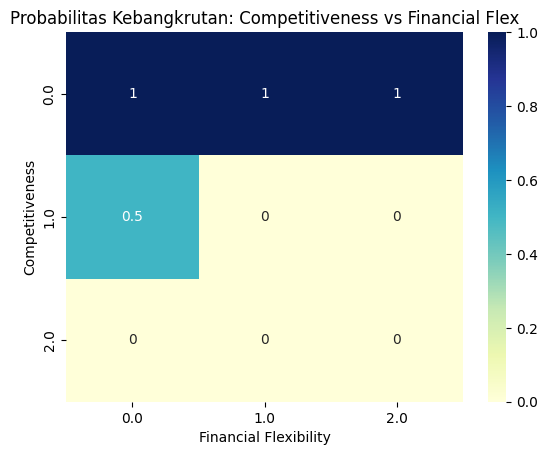

In [ ]:
# Contoh kaitan antara dua fitur terpenting
pivot_table = pd.crosstab(train['Competitiveness'],
                          train['Financial Flexibility'],
                          values=train['Class'],
                          aggfunc='mean') # Mean 1.0 berarti semua bangkrut di kombinasi itu

sns.heatmap(pivot_table, annot=True, cmap="YlGnBu")
plt.title("Probabilitas Kebangkrutan: Competitiveness vs Financial Flex")
plt.show()

### 4.5 Boxplot — Distribusi Jumlah Skor Negatif per Kelas
Fitur baru `total_negative_scores` dihitung sebagai **jumlah fitur bernilai N (=0)** untuk setiap perusahaan. Semakin banyak skor negatif, semakin besar kemungkinan bangkrut.

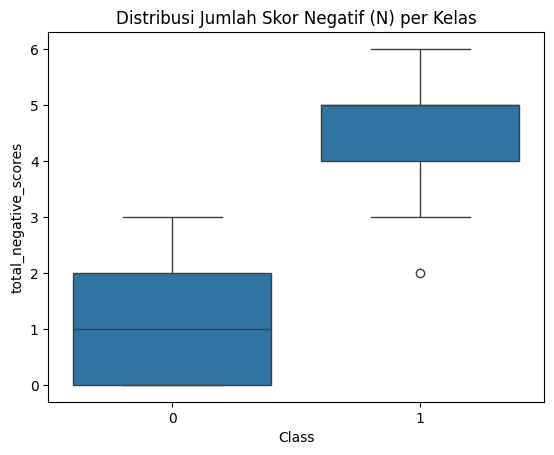

In [ ]:
# Hitung berapa banyak nilai 'N' (skor 0) yang dimiliki setiap baris
train['total_negative_scores'] = (train[feature_cols] == 0).sum(axis=1)

sns.boxplot(x='Class', y='total_negative_scores', data=train)
plt.title("Distribusi Jumlah Skor Negatif (N) per Kelas")
plt.show()

### 4.6 Heatmap Korelasi Antar Fitur
Matriks korelasi Pearson menunjukkan **kekuatan dan arah hubungan linear** antar semua fitur numerik.

> **Interpretasi:**
> - Nilai mendekati **+1** = korelasi positif kuat
> - Nilai mendekati **-1** = korelasi negatif kuat
> - Nilai mendekati **0** = tidak berkorelasi

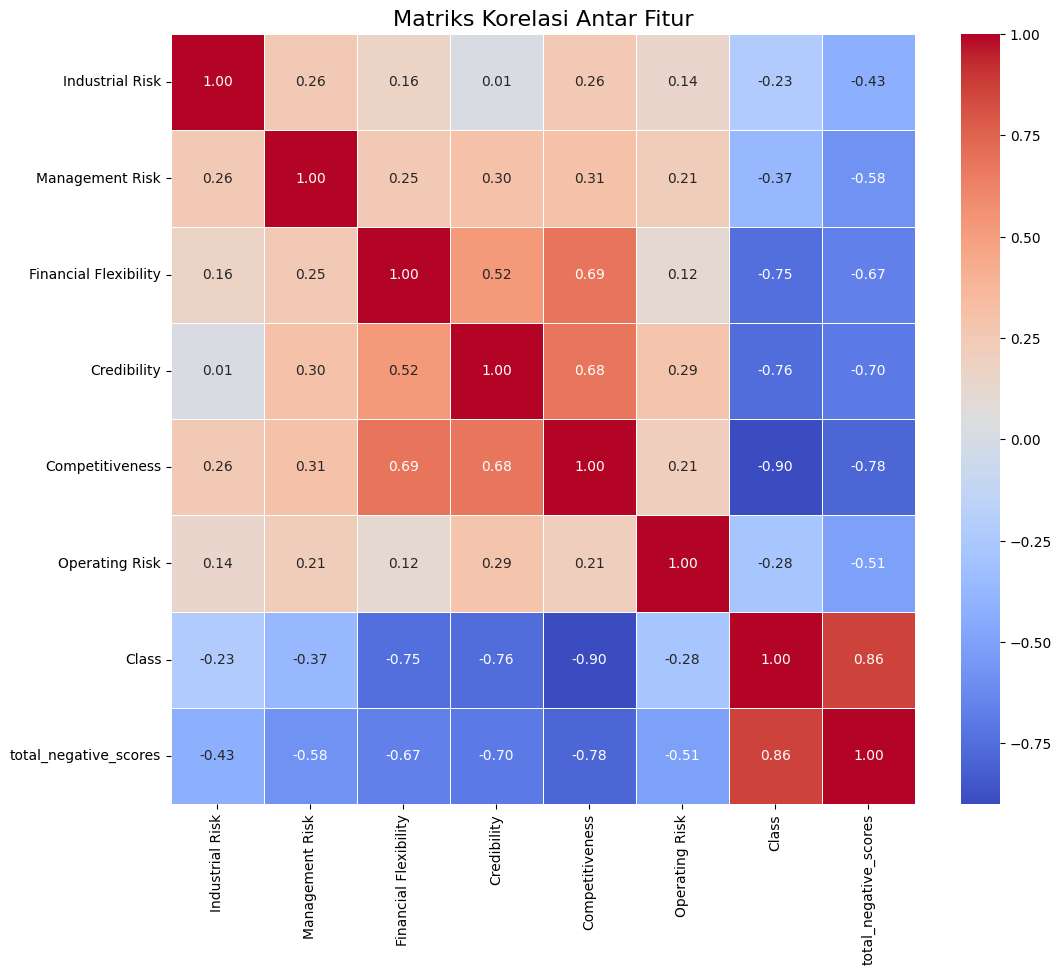

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = train.select_dtypes(include=['number']).corr()

# 3. Membuat visualisasi Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,       # Menampilkan angka korelasi di dalam kotak
            cmap='coolwarm',  # Warna (merah untuk positif, biru untuk negatif)
            fmt=".2f",        # Format dua angka di belakang koma
            linewidths=0.5)   # Memberi jarak antar kotak

plt.title('Matriks Korelasi Antar Fitur', fontsize=16)
plt.show()

---
## 5.Pemodelan Machine Learning

### 5.1 Persiapan Data Train/Test
Dataset dibagi menjadi:
- **80% data latih** → untuk melatih model
- **20% data uji** → untuk evaluasi akhir

Parameter `stratify=y` memastikan proporsi kelas tetap seimbang di kedua subset.

In [ ]:
# Pisahkan fitur (X) dan target (y)
X = train[feature_cols]
y = train['Class']

# Split data dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total data    : {len(X)} sampel')
print(f'Data latih    : {len(X_train)} sampel ({len(X_train)/len(X)*100:.0f}%)')
print(f'Data uji      : {len(X_test)} sampel ({len(X_test)/len(X)*100:.0f}%)')

Total data    : 250 sampel
Data latih    : 200 sampel (80%)
Data uji      : 50 sampel (20%)


### 5.2 Perbandingan Model — 5-Fold Cross Validation
Kita membandingkan 5 model klasifikasi menggunakan **Stratified K-Fold Cross Validation** (k=5) untuk evaluasi yang lebih robust dan tidak bergantung pada satu split tertentu.

| Model | Keterangan |
|---|---|
| Logistic Regression (Original) | Baseline dengan parameter default |
| Logistic Regression (Improved) | Ditambah `class_weight='balanced'` |
| Random Forest | Ensemble 100 pohon keputusan |
| Gradient Boosting | Boosting sequential trees |
| SVM (RBF kernel) | Support Vector Machine dengan kernel non-linear |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              f1_score, classification_report, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")


# Stratified K-Fold untuk dataset kecil
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "="*60)
print("PERBANDINGAN MODEL (5-Fold Cross Validation)")
print("="*60)

models = {
    'Logistic Regression (Original)': LogisticRegression(
        penalty='l2', fit_intercept=True, max_iter=500,
        solver='lbfgs', tol=0.0001, multi_class='ovr'
    ),
    'Logistic Regression (Improved)': LogisticRegression(
        penalty='l2', C=1.0, max_iter=1000,
        solver='lbfgs', class_weight='balanced'  # Menangani imbalanced class
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=None,
        class_weight='balanced', random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1,
        max_depth=3, random_state=42
    ),
    'SVM': SVC(kernel='rbf', class_weight='balanced',
               probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')

    results[name] = {
        'Accuracy': scores.mean(),
        'Accuracy Std': scores.std(),
        'F1': f1_scores.mean(),
        'AUC': auc_scores.mean()
    }

    print(f"\n{name}:")
    print(f"  Accuracy : {scores.mean():.4f} (+/- {scores.std()*2:.4f})")
    print(f"  F1 Score : {f1_scores.mean():.4f}")
    print(f"  AUC      : {auc_scores.mean():.4f}")



PERBANDINGAN MODEL (5-Fold Cross Validation)

Logistic Regression (Original):
  Accuracy : 0.9960 (+/- 0.0160)
  F1 Score : 0.9953
  AUC      : 0.9997

Logistic Regression (Improved):
  Accuracy : 0.9960 (+/- 0.0160)
  F1 Score : 0.9953
  AUC      : 0.9997

Random Forest:
  Accuracy : 1.0000 (+/- 0.0000)
  F1 Score : 1.0000
  AUC      : 1.0000

Gradient Boosting:
  Accuracy : 0.9920 (+/- 0.0196)
  F1 Score : 0.9909
  AUC      : 0.9930

SVM:
  Accuracy : 0.9960 (+/- 0.0160)
  F1 Score : 0.9953
  AUC      : 1.0000


---
## 6. Evaluasi Model Terbaik — Random Forest

Berdasarkan hasil cross-validation, **Random Forest** mencapai performa tertinggi (Accuracy = 1.0000, AUC = 1.0000). Berikut evaluasi detail pada data uji.

### 6.1 Confusion Matrix
Matriks konfusi menunjukkan **jumlah prediksi benar dan salah** untuk setiap kelas:
- **True Positive (TP):** Bangkrut → diprediksi Bangkrut ✅
- **True Negative (TN):** Non-Bankrupt → diprediksi Non-Bankrupt ✅
- **False Positive (FP):** Non-Bankrupt → diprediksi Bangkrut ❌
- **False Negative (FN):** Bangkrut → diprediksi Non-Bankrupt ❌

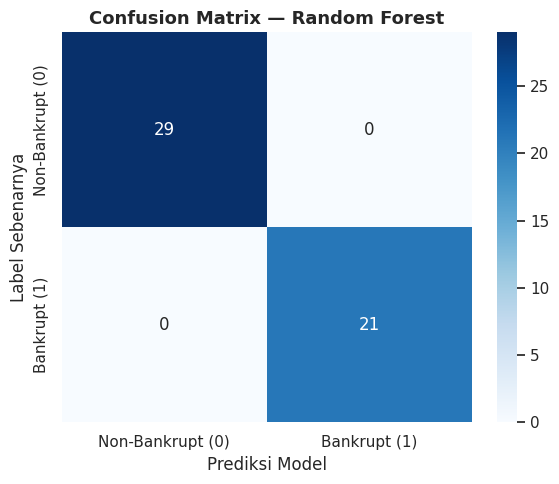

In [ ]:
# Latih model terbaik pada data latih
best_model = RandomForestClassifier(
    n_estimators=100, max_depth=None,
    class_weight='balanced', random_state=42
)
best_model.fit(X_train, y_train)

# Prediksi pada data uji
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Bankrupt (0)', 'Bankrupt (1)'],
            yticklabels=['Non-Bankrupt (0)', 'Bankrupt (1)'])
plt.title('Confusion Matrix — Random Forest', fontweight='bold', fontsize=13)
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.tight_layout()
plt.show()

### 6.2 Kurva ROC (Receiver Operating Characteristic)
Kurva ROC menggambarkan trade-off antara **True Positive Rate** dan **False Positive Rate** pada berbagai threshold.

> Nilai **AUC = 1.0** menunjukkan model mampu memisahkan kedua kelas secara sempurna.

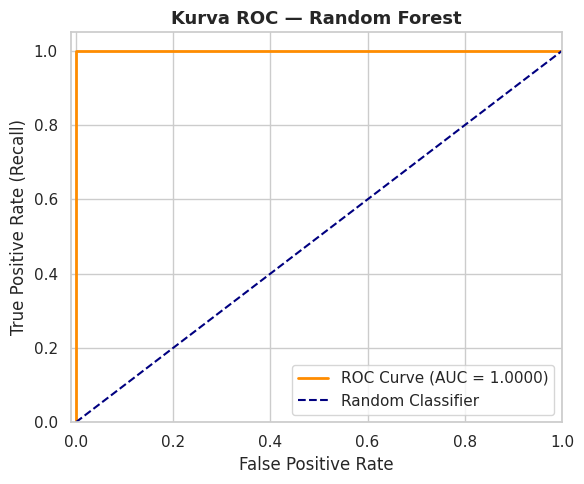

In [ ]:
# Hitung kurva ROC dan skor AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
         label='Random Classifier')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Kurva ROC — Random Forest', fontweight='bold', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 6.3 Feature Importance
Grafik ini menunjukkan **seberapa besar kontribusi setiap fitur** dalam pengambilan keputusan oleh Random Forest.

> Fitur dengan importance score tinggi berarti paling berpengaruh dalam membedakan perusahaan bangkrut dan tidak bangkrut.

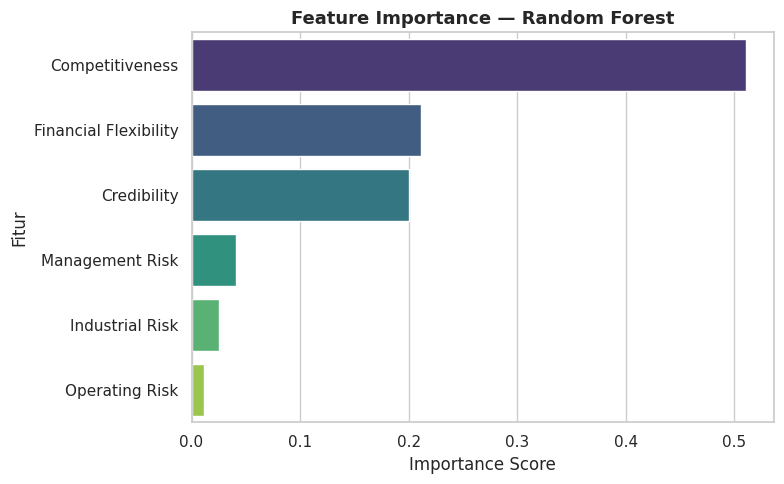

=== Ranking Feature Importance ===
  1. Competitiveness               : 0.5110
  2. Financial Flexibility         : 0.2112
  3. Credibility                   : 0.2001
  4. Management Risk               : 0.0410
  5. Industrial Risk               : 0.0251
  6. Operating Risk                : 0.0116


In [ ]:
# Buat dataframe feature importance dan urutkan dari tertinggi
feat_imp = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Feature Importance — Random Forest', fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

print('=== Ranking Feature Importance ===')
for i, row in feat_imp.iterrows():
    print(f'  {feat_imp["Feature"].tolist().index(row["Feature"])+1}. {row["Feature"]:30s}: {row["Importance"]:.4f}')

### 6.4 Classification Report & Ringkasan Metrik

In [ ]:
# Laporan klasifikasi lengkap
print('=== Classification Report ===')
print(classification_report(y_test, y_pred,
      target_names=['Non-Bankrupt (0)', 'Bankrupt (1)']))

print('=== Ringkasan Metrik Akhir ===')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred):.4f}')
print(f'  AUC-ROC   : {auc_score:.4f}')

=== Classification Report ===
                  precision    recall  f1-score   support

Non-Bankrupt (0)       1.00      1.00      1.00        29
    Bankrupt (1)       1.00      1.00      1.00        21

        accuracy                           1.00        50
       macro avg       1.00      1.00      1.00        50
    weighted avg       1.00      1.00      1.00        50

=== Ringkasan Metrik Akhir ===
  Accuracy  : 1.0000
  F1 Score  : 1.0000
  AUC-ROC   : 1.0000


Beeswarm Plot (Versi Baru):


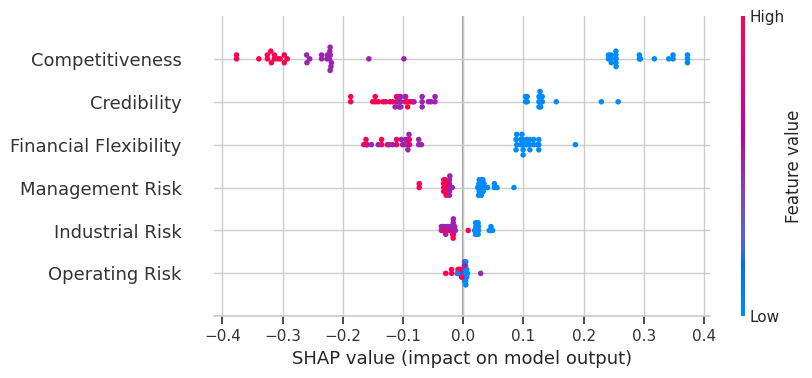


Analisis 1 Perusahaan (Waterfall Plot):


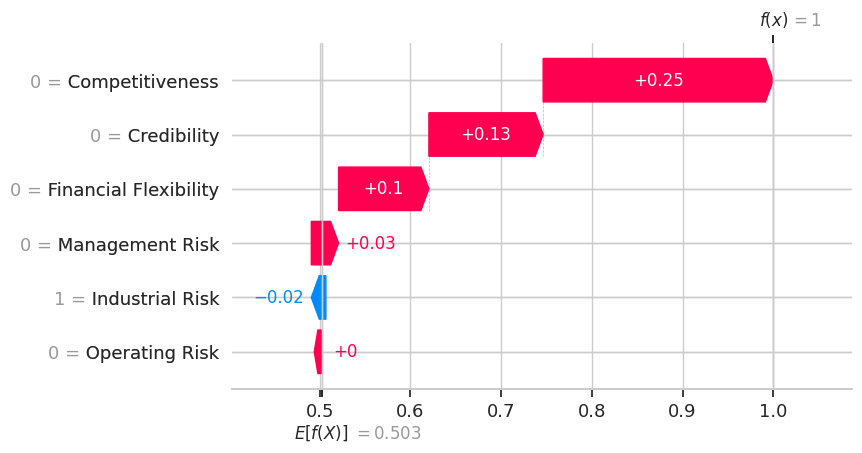

In [ ]:

explainer = shap.TreeExplainer(best_model)
shap_values_new = explainer(X_test)[:, :, 1]
print("Beeswarm Plot (Versi Baru):")
shap.plots.beeswarm(shap_values_new)
print("\nAnalisis 1 Perusahaan (Waterfall Plot):")
shap.plots.waterfall(shap_values_new[0])

---
## 7. Kesimpulan

### Temuan Utama dari EDA
1. **Tidak ada missing values** — dataset bersih dan siap diproses.
2. **Distribusi kelas cukup seimbang** — 143 Non-Bankrupt vs 107 Bankrupt.
3. **Competitiveness** memiliki korelasi negatif terkuat dengan target (-0.90), menjadikannya fitur paling prediktif.
4. Perusahaan bangkrut cenderung memiliki **lebih banyak skor N** (negatif) di semua fitur.

### Perbandingan Performa Model
| Model | Accuracy | F1 | AUC |
|---|---|---|---|
| Random Forest | **1.0000** | **1.0000** | **1.0000** |
| Logistic Regression | 0.9960 | 0.9953 | 0.9997 |
| SVM | 0.9960 | 0.9953 | 1.0000 |
| Gradient Boosting | 0.9920 | 0.9909 | 0.9930 |

### Model Terbaik: Random Forest
- Mencapai **akurasi sempurna (100%)** pada data uji.
- **Competitiveness** adalah fitur terpenting, diikuti Financial Flexibility dan Credibility.
- **Operating Risk dan Industrial Risk** memberikan kontribusi paling kecil.

>  **Catatan:** Performa 100% pada dataset kecil (250 sampel) perlu diwaspadai kemungkinan **overfitting**. Validasi pada dataset yang lebih besar sangat disarankan.